In [3]:
import numpy as np
import pywt

def detect_spikes_wavelet_pywt(
    signal,
    fs,
    scale_ms=1.0,
    threshold_factor=4.0,
    min_distance_ms=1.0
):
    """
    Wavelet-based spike detection using PyWavelets (mexh wavelet).

    Parameters
    ----------
    signal : 1D array
        Neural voltage trace.
    fs : float
        Sampling frequency in Hz.
    scale_ms : float
        Wavelet scale in milliseconds (approx spike width).
    threshold_factor : float
        Threshold = threshold_factor * MAD.
    min_distance_ms : float
        Minimum refractory period between spikes.

    Returns
    -------
    spike_times : array
        Detected spike times in seconds.
    spike_indices : array
        Indices of detected spikes in the original signal.
    """

    # Convert ms → samples
    scale_samples = scale_ms * 1e-3 * fs
    min_distance = int(min_distance_ms * 1e-3 * fs)

    # PyWavelets expects scales as an array
    coeffs, _ = pywt.cwt(signal, scales=[scale_samples], wavelet='mexh')
    coeffs = coeffs[0]  # single scale

    # Robust noise estimate (MAD)
    sigma = np.median(np.abs(coeffs)) / 0.6745
    threshold = threshold_factor * sigma

    # Threshold crossings
    candidate_idx = np.where(np.abs(coeffs) > threshold)[0]

    # Enforce refractory period
    spike_indices = []
    last = -np.inf

    for idx in candidate_idx:
        if idx - last > min_distance:
            spike_indices.append(idx)
            last = idx

    spike_indices = np.array(spike_indices)
    spike_times = spike_indices / fs

    return spike_times, spike_indices

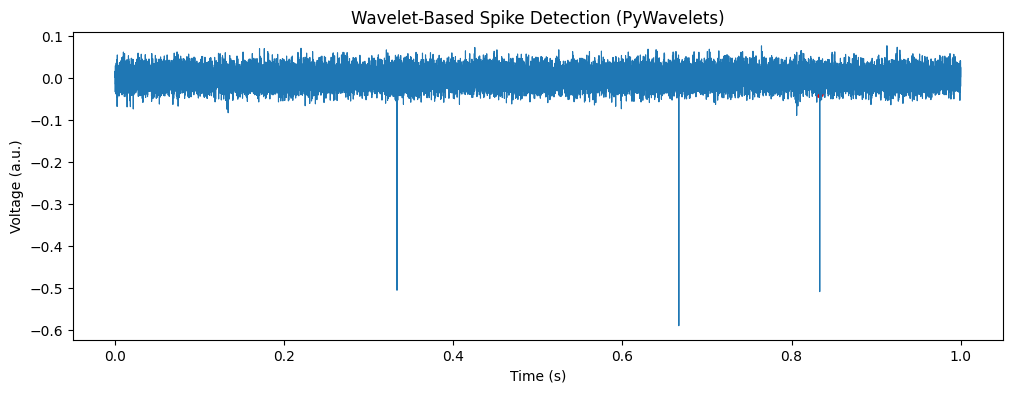

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fs = 30000
t = np.arange(0, 1, 1/fs)

# Fake spikes
signal = 0.02 * np.random.randn(len(t))
signal[10000] -= 0.5
signal[20000] -= 0.6
signal[25000] -= 0.55   # valid index

spike_times, spike_idx = detect_spikes_wavelet_pywt(signal, fs)

plt.figure(figsize=(12,4))
plt.plot(t, signal, linewidth=0.8)
plt.scatter(spike_times, signal[spike_idx], color='red', s=30)
plt.title("Wavelet-Based Spike Detection (PyWavelets)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (a.u.)")
plt.show()

In [8]:
spike_times

array([0.33293333, 0.83283333])